# Cosine vs Euclidean distance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Simple 2D vectors
A = np.array([[1, 2]])
B = np.array([[2, 4]])   # Same direction, scaled
C = np.array([[2, 0]])   # Different direction

print("---- A vs B ----")
print("Euclidean:", euclidean_distances(A, B)[0][0])
print("Cosine:", cosine_similarity(A, B)[0][0])

print("\n---- A vs C ----")
print("Euclidean:", euclidean_distances(A, C)[0][0])
print("Cosine:", cosine_similarity(A, C)[0][0])

---- A vs B ----
Euclidean: 2.23606797749979
Cosine: 0.9999999999999999

---- A vs C ----
Euclidean: 2.23606797749979
Cosine: 0.4472135954999579


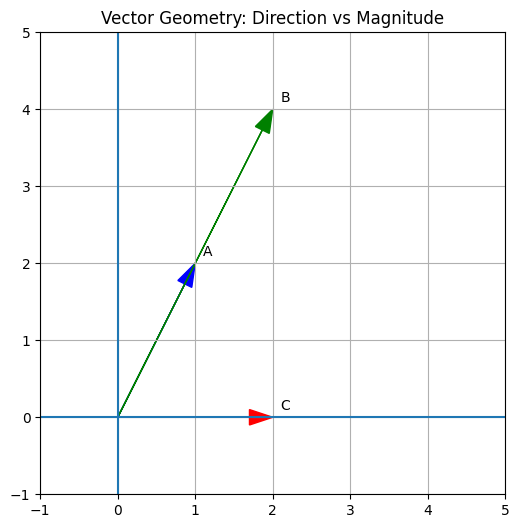

In [2]:
plt.figure(figsize=(6,6))

vectors = {"A": A[0], "B": B[0], "C": C[0]}
colors = {"A": "blue", "B": "green", "C": "red"}

for name, vec in vectors.items():
    plt.arrow(0, 0, vec[0], vec[1],
              head_width=0.2,
              color=colors[name],
              length_includes_head=True)
    plt.text(vec[0]+0.1, vec[1]+0.1, name)

plt.xlim(-1,5)
plt.ylim(-1,5)
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.title("Vector Geometry: Direction vs Magnitude")
plt.show()

# Scaling problem

In [3]:
D = np.array([[10, 20]])  # Same direction, bigger scale

print("Euclidean A-D:", euclidean_distances(A, D)[0][0])
print("Cosine A-D:", cosine_similarity(A, D)[0][0])

Euclidean A-D: 20.12461179749811
Cosine A-D: 0.9999999999999999


# Apply to Real word Embeddings

/Users/gourasundarmohanty/miniconda3/envs/py313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1743.37it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


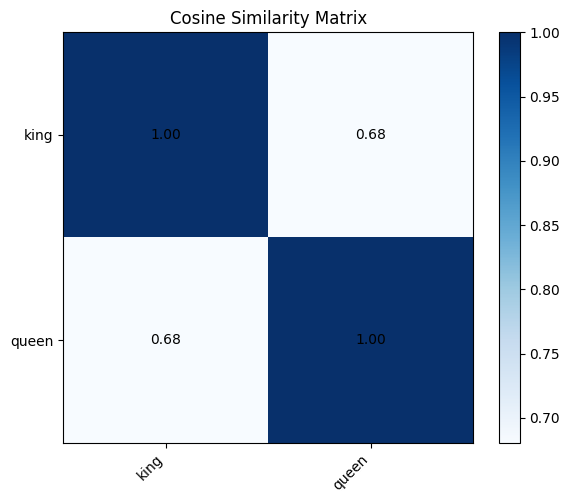

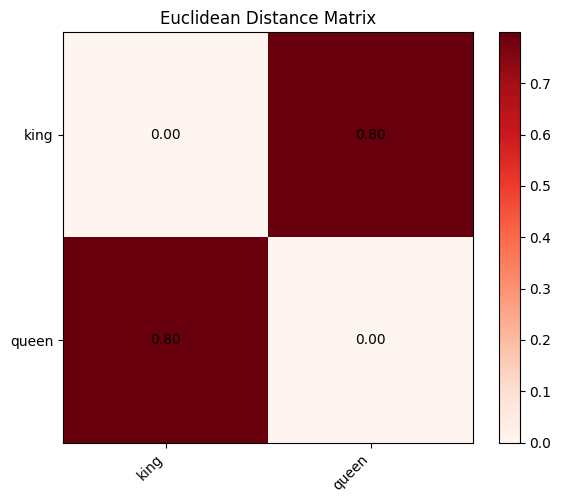

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sentence_transformers import SentenceTransformer

# Example sentences
words_list = [
    "king",
    "queen"
]

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(words_list)

# Compute similarity metrics
cos_sim = cosine_similarity(embeddings)
euc_dist = euclidean_distances(embeddings)

# Function to plot heatmap
def plot_matrix(matrix, title, cmap):
    plt.figure(figsize=(6,5))
    plt.imshow(matrix, cmap=cmap)
    plt.colorbar()
    plt.xticks(range(len(words_list)), words_list, rotation=45, ha='right')
    plt.yticks(range(len(words_list)), words_list)
    plt.title(title)
    
    # Add numbers inside cells
    for i in range(len(words_list)):
        for j in range(len(words_list)):
            plt.text(j, i, f"{matrix[i, j]:.2f}",
                     ha="center", va="center", color="black")
    
    plt.tight_layout()
    plt.show()

# Plot Cosine Similarity
plot_matrix(cos_sim, "Cosine Similarity Matrix", "Blues")

# Plot Euclidean Distance
plot_matrix(euc_dist, "Euclidean Distance Matrix", "Reds")

# Apply to Real Sentence Embeddings

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 898.15it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


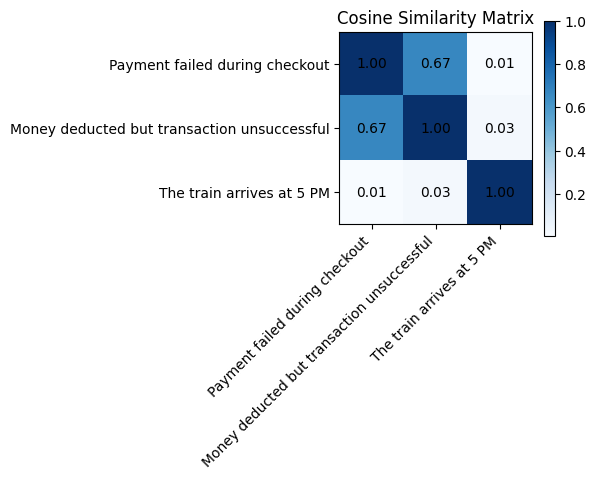

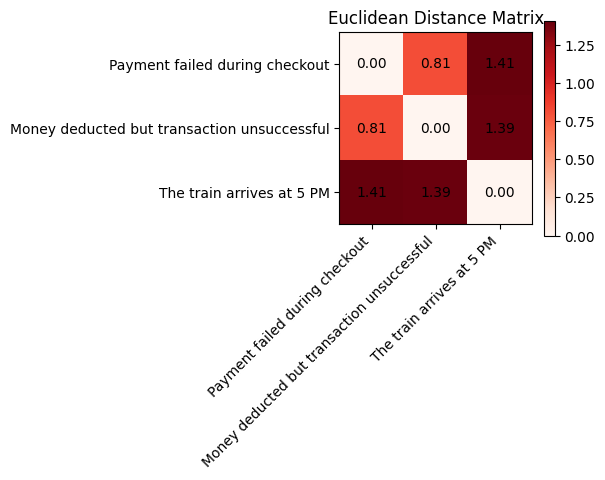

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sentence_transformers import SentenceTransformer

# Example sentences
sentences = [
    "Payment failed during checkout",
    "Money deducted but transaction unsuccessful",
    "The train arrives at 5 PM"
]

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

# Compute similarity metrics
cos_sim = cosine_similarity(embeddings)
euc_dist = euclidean_distances(embeddings)

# Function to plot heatmap
def plot_matrix(matrix, title, cmap):
    plt.figure(figsize=(6,5))
    plt.imshow(matrix, cmap=cmap)
    plt.colorbar()
    plt.xticks(range(len(sentences)), sentences, rotation=45, ha='right')
    plt.yticks(range(len(sentences)), sentences)
    plt.title(title)
    
    # Add numbers inside cells
    for i in range(len(sentences)):
        for j in range(len(sentences)):
            plt.text(j, i, f"{matrix[i, j]:.2f}",
                     ha="center", va="center", color="black")
    
    plt.tight_layout()
    plt.show()

# Plot Cosine Similarity
plot_matrix(cos_sim, "Cosine Similarity Matrix", "Blues")

# Plot Euclidean Distance
plot_matrix(euc_dist, "Euclidean Distance Matrix", "Reds")

# Distance metrics - Images & Pixels

In [10]:
!pip install numpy matplotlib pillow requests scikit-learn

Average RGB Image 1: [[ 99.7662 136.913  150.5998]]
Average RGB Image 2: [[115.2728  30.7297  38.7819]]

Euclidean Distance: 154.97932314621843
Cosine Similarity: 0.7578252768578057


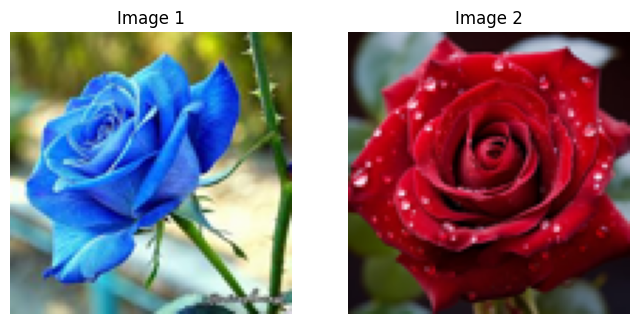

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

# Open-source sample images (Wikimedia)
url1 = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS803rjWx04_W9xVxYKVgL_eenzOZrdD2bGWw&s"
url2 = "https://static.vecteezy.com/system/resources/previews/056/313/111/large_2x/elegant-single-blue-rose-with-stem-photo.jpg"
# url2 = "https://images.stockcake.com/public/5/1/8/5181369d-e3c2-4a74-b426-5fddbcba1228_large/dewy-red-rose-stockcake.jpg"

# Download images
response1 = requests.get(url1)
response2 = requests.get(url2)

img1 = Image.open(BytesIO(response1.content)).resize((100,100))
img2 = Image.open(BytesIO(response2.content)).resize((100,100))

# Convert to numpy arrays
arr1 = np.array(img1)
arr2 = np.array(img2)

# Compute average RGB values
avg1 = arr1.mean(axis=(0,1)).reshape(1,-1)
avg2 = arr2.mean(axis=(0,1)).reshape(1,-1)

print("Average RGB Image 1:", avg1)
print("Average RGB Image 2:", avg2)

# Compute Euclidean distance
euc_dist = euclidean_distances(avg1, avg2)[0][0]

# Compute Cosine similarity
cos_sim = cosine_similarity(avg1, avg2)[0][0]

print("\nEuclidean Distance:", euc_dist)
print("Cosine Similarity:", cos_sim)

# Display images
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis("off")

plt.show()